# Making a neural network model that predicts which digit (0–9) is in a 28×28 grayscale image

In [2]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models



## Load dataset


In [3]:
(x_train,y_train),(x_test,y_test) = tf.keras.datasets.mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [4]:
x_test.shape

(10000, 28, 28)

In [5]:
y_train.shape

(60000,)

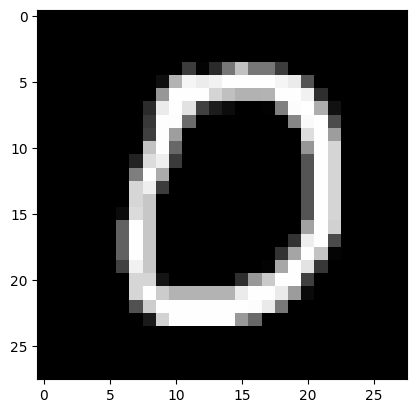

In [6]:
plt.imshow(x_test[10],cmap="gray")

# Create Model

In [7]:
model = models.Sequential([
    layers.Flatten(),
    layers.Dense(128,activation="relu"),
    layers.Dense(10,activation="softmax")

])

# Compile the model


In [8]:
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics = ['accuracy'])

# Train model

In [9]:
model.fit(x_train,y_train,epochs = 5)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.8183 - loss: 8.7471
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9081 - loss: 0.4116
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9333 - loss: 0.2658
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9391 - loss: 0.2459
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9453 - loss: 0.2195


# Evaluate model


In [10]:
test_accuracy, test_loss = model.evaluate(x_test,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9289 - loss: 0.3261


In [11]:
predictions = model.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


In [12]:
predictions.shape

(10000, 10)

In [13]:
print(np.argmax(predictions[10
                            ]))

0


In [14]:
y_test[10]

np.uint8(0)

In [20]:
print(model.predict(x_test))

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
[[4.9456912e-33 8.1239902e-12 6.6104830e-11 ... 9.9999613e-01
  2.3976475e-24 3.8574473e-12]
 [2.0519982e-30 1.2054063e-07 9.9955302e-01 ... 1.9214229e-11
  1.7839723e-13 1.1998037e-24]
 [1.2017261e-10 9.9997193e-01 1.2389944e-09 ... 1.7195207e-05
  1.0817353e-05 8.3438387e-15]
 ...
 [1.3146927e-27 1.8823750e-22 2.2398550e-16 ... 1.9593070e-10
  4.3503731e-13 1.0215084e-11]
 [1.2903421e-08 2.5104600e-14 1.9444547e-27 ... 4.1005542e-06
  1.6852258e-05 7.0256311e-28]
 [1.3666940e-12 2.6373706e-25 2.0178954e-11 ... 5.2588332e-13
  4.8651487e-20 9.2479322e-29]]


## Save Model

In [22]:
model.save('firstmodel.h5')
print("Model Saved!")

loaded_model = tf.keras.models.load_model('firstmodel.h5')

loss, acc = loaded_model.evaluate(x_test, y_test)
print(f"Loaded Model Accuracy: {acc*100:.2f}%")

Model Saved!
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9289 - loss: 0.3261
Loaded Model Accuracy: 93.97%
